In [ ]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random

nltk.download('twitter_samples')
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


In [ ]:
print('Number of positive tweets: ', len(all_positive_tweets))
print('Number of negative tweets: ', len(all_negative_tweets))

print('\nThe type of all positive tweets is: ', type(all_positive_tweets))
print('The type of a tweet entry is: ', type(all_negative_tweets[0]))

Number of positive tweets:  5000
Number of negative tweets:  5000

The type of all positive tweets is:  <class 'list'>
The type of a tweet entry is:  <class 'str'>


In [ ]:
import pandas as pd

df = pd.DataFrame({
    'tweet': all_positive_tweets + all_negative_tweets,
    'sentiment': ['positive'] * len(all_positive_tweets) +
                 ['negative'] * len(all_negative_tweets)
})

print(df.shape)

(10000, 2)


In [ ]:
positive_tweets=pd.DataFrame(all_positive_tweets,columns=['Tweets']).head()
negative_tweets=pd.DataFrame(all_negative_tweets,columns=['Tweets']).head()
positive_tweets['sentiment']='positive'
negative_tweets['sentiment']='negative'

In [ ]:
positive_tweets

,Tweets,sentiment
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [ ]:
negative_tweets

,Tweets,sentiment
0,hopeless for tmr :(,negative
1,Everything in the kids section of IKEA is so c...,negative
2,@Hegelbon That heart sliding into the waste ba...,negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",negative
4,"Dang starting next week I have ""work"" :(",negative


In [ ]:
all_tweets = all_positive_tweets + all_negative_tweets

In [ ]:
import pandas as pd

# Convert the list all_tweets to a pandas DataFrame
all_tweets = pd.DataFrame(all_tweets, columns=['Tweets'])
all_tweets = all_tweets.sample(frac=1, random_state=42).reset_index(drop=True)
all_tweets

,Tweets
0,"I love you, how but you? @Taecyeon2pm8 did you..."
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...
2,"Your love, O Lord, is better than life. :) &lt..."
3,@yasminyasir96 yeah but it will be better if w...
4,Ok good night I wish troye wasn't ugly and I m...
...,...
9995,My nose and forehead are peeling :(
9996,@LittleMix come to Belgium :(
9997,WHY MUST THE VIDEO STOP THO :(
9998,@jeremygutsche we like this amazing donut reci...


In [ ]:
tweet1=all_tweets.iloc[1000]
tweet1["Tweets"]

'@djcunningham Thanks for the favorite! :) Make sure to keep in touch for more news of our light bulbs made from corn waste.'

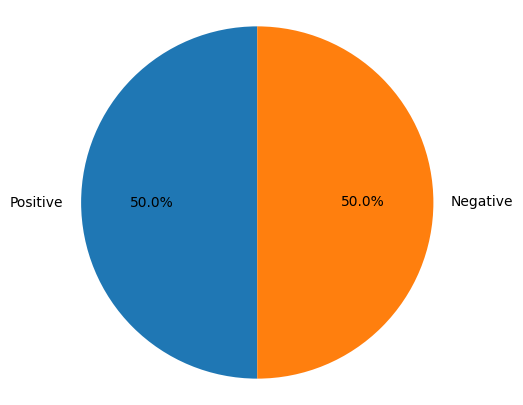

In [ ]:
import matplotlib.pyplot as plt

# Count positive and negative tweets
y_positive = len(all_positive_tweets)
y_negative = len(all_negative_tweets)

# Declare a figure with a custom size
fig = plt.figure(figsize=(5, 5))

# Labels for the two classes
labels = ['Positive', 'Negative']

# Sizes for each slice
sizes = [y_positive, y_negative]

# Create the pie chart
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

# Keep the pie chart circular
plt.axis('equal')

# Display the chart
plt.show()

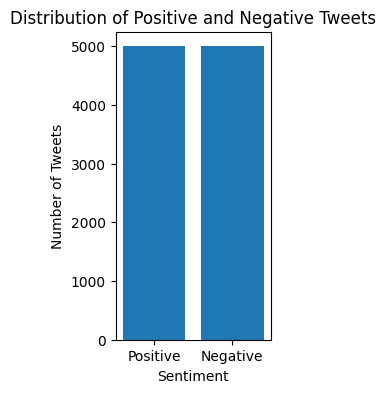

In [ ]:
# Labels and values
labels = ['Positive', 'Negative']
counts = [y_positive, y_negative]

# Create bar chart
plt.figure(figsize=(2, 4))
plt.bar(labels, counts)

# Add title and labels
plt.title('Distribution of Positive and Negative Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

plt.show()

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import re

# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet1["Tweets"])

# remove hyperlinks
tweet2 = re.sub(r'https?:\/\/[\S]+', '', tweet2)

# remove hashtags
# only removing the hash # sign from the word
tweet2 = re.sub(r'#', '', tweet2)

# remove @ mentions
tweet2 = re.sub(r'@\w+', '', tweet2)

# remove punctuation
tweet2 = re.sub(r'[:,.!?()]', '', tweet2)

print(tweet1["Tweets"])
print("\nCleaned tweet: ", tweet2)

@djcunningham Thanks for the favorite! :) Make sure to keep in touch for more news of our light bulbs made from corn waste.

Cleaned tweet:   Thanks for the favorite  Make sure to keep in touch for more news of our light bulbs made from corn waste


In [ ]:
from nltk.tokenize import TweetTokenizer

tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

# tokenize tweets
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenized string:\n')
print(tweet_tokens)


Tokenized string:

['thanks', 'for', 'the', 'favorite', 'make', 'sure', 'to', 'keep', 'in', 'touch', 'for', 'more', 'news', 'of', 'our', 'light', 'bulbs', 'made', 'from', 'corn', 'waste']
